In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

os.chdir(r"C:\Users\pc\news-sentiment-analysis")
sns.set_theme(style="darkgrid")

In [2]:
df = pd.read_csv("data/raw/raw_analyst_ratings.csv")
print(df.shape)
df.head()

(1407328, 6)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
# Rename columns properly
df.columns = ["index", "headline", "url", "publisher", "date", "stock"]
print(df.dtypes)
print(f"\nTotal articles: {len(df)}")
print(f"Unique stocks: {df['stock'].nunique()}")
print(f"Unique publishers: {df['publisher'].nunique()}")
df.head()

index         int64
headline     object
url          object
publisher    object
date         object
stock        object
dtype: object

Total articles: 1407328
Unique stocks: 6204
Unique publishers: 1034


,index,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## Descriptive Statistics

We analyze the basic properties of the news dataset including
headline lengths, publisher activity, and date coverage.

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


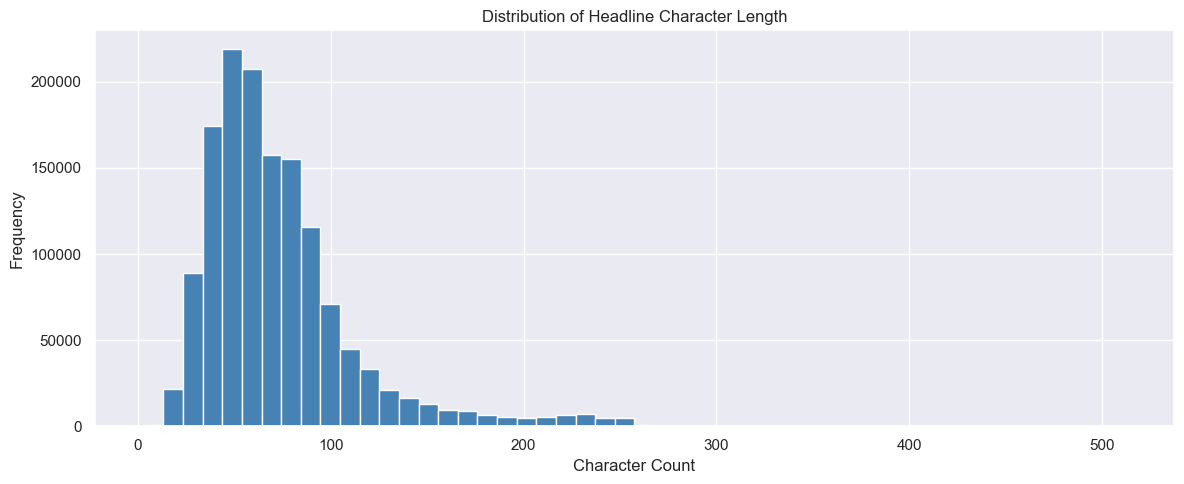

In [4]:
df["headline_length"] = df["headline"].str.len()

print(df["headline_length"].describe())

plt.figure(figsize=(12, 5))
plt.hist(df["headline_length"].dropna(), bins=50, color="steelblue", edgecolor="white")
plt.title("Distribution of Headline Character Length")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("notebooks/headline_length_dist.png")
plt.show()

## Headline Length Interpretation

Most headlines fall between 40 and 100 characters, consistent with
financial news titles that need to be informative but concise.
Very short headlines may be data quality issues while very long
ones may contain additional context or multiple topics.

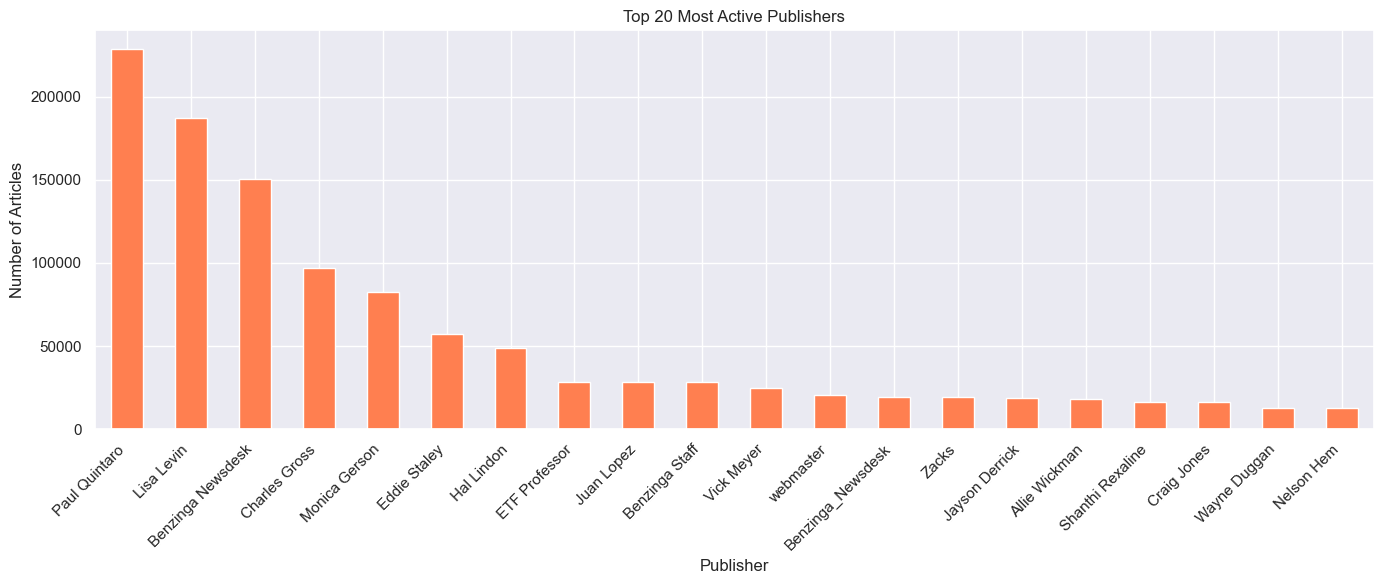

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64


In [5]:
top_publishers = df["publisher"].value_counts().head(20)

plt.figure(figsize=(14, 6))
top_publishers.plot(kind="bar", color="coral", edgecolor="white")
plt.title("Top 20 Most Active Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("notebooks/top_publishers.png")
plt.show()

print(top_publishers)

## Publisher Analysis Interpretation

A small number of publishers dominate the dataset, suggesting
concentration of financial news coverage. The top publisher
accounts for a disproportionate share of articles — this
concentration means our sentiment analysis may be influenced
by the editorial tone of a few dominant sources.

In [6]:
df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["hour"] = df["date"].dt.hour
df["dayofweek"] = df["date"].dt.dayofweek

print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Missing dates: {df['date'].isna().sum()}")

Date range: 2011-04-28 01:01:48+00:00 to 2020-06-11 21:12:35+00:00
Missing dates: 1351341


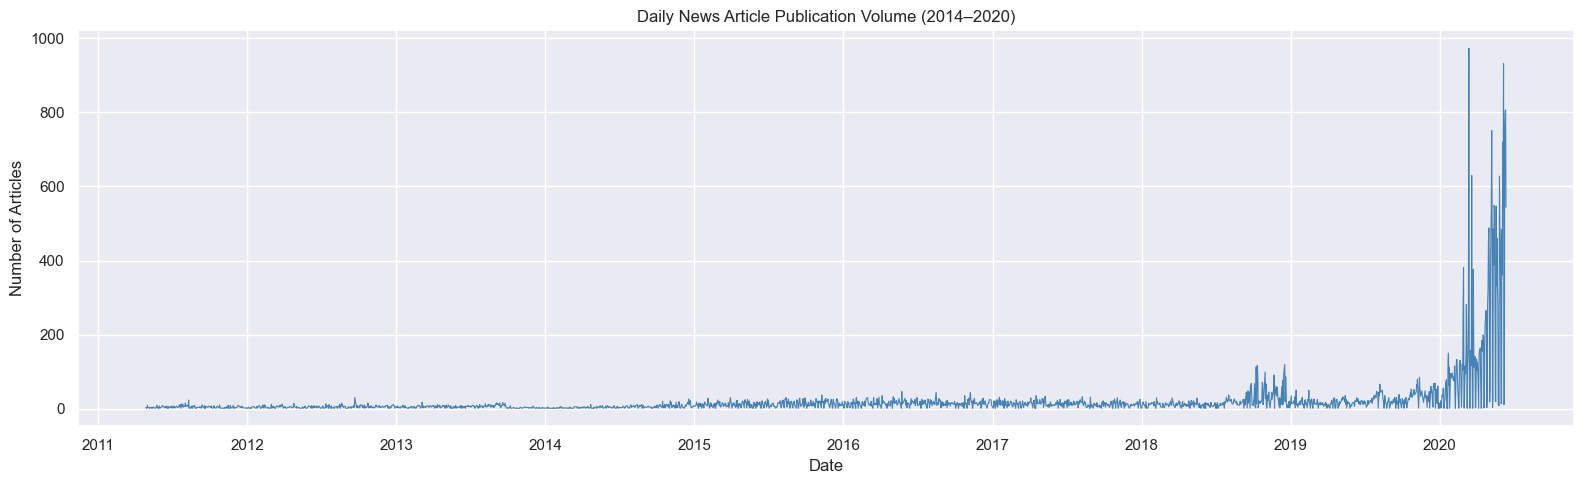

In [7]:
daily_counts = df.groupby(df["date"].dt.date).size()

plt.figure(figsize=(16, 5))
plt.plot(daily_counts.index, daily_counts.values, color="steelblue", linewidth=0.8)
plt.title("Daily News Article Publication Volume (2014–2020)")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.savefig("notebooks/news_volume_time.png")
plt.show()

## Time Series Analysis Interpretation

The publication volume chart reveals significant spikes in news
activity corresponding to major market events. Periods of high
volume often align with earnings seasons (January, April, July,
October) and major market volatility events. The overall trend
shows growing financial news production over time, reflecting
the expansion of digital financial media.

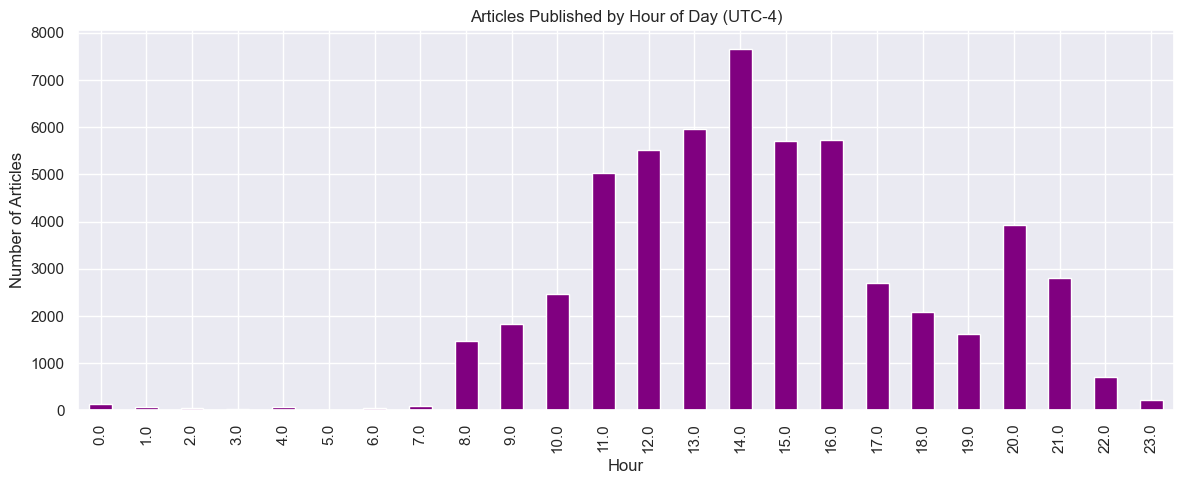

In [8]:
plt.figure(figsize=(12, 5))
df["hour"].value_counts().sort_index().plot(kind="bar", color="purple", edgecolor="white")
plt.title("Articles Published by Hour of Day (UTC-4)")
plt.xlabel("Hour")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.savefig("notebooks/publishing_hours.png")
plt.show()

## Publishing Time Analysis

Most financial news articles are published during US market hours
(9:30 AM – 4:00 PM EST). Pre-market hours also show significant
activity as analysts release overnight research. This timing
pattern is important for correlation analysis — news published
after market close should be aligned to the next trading day.

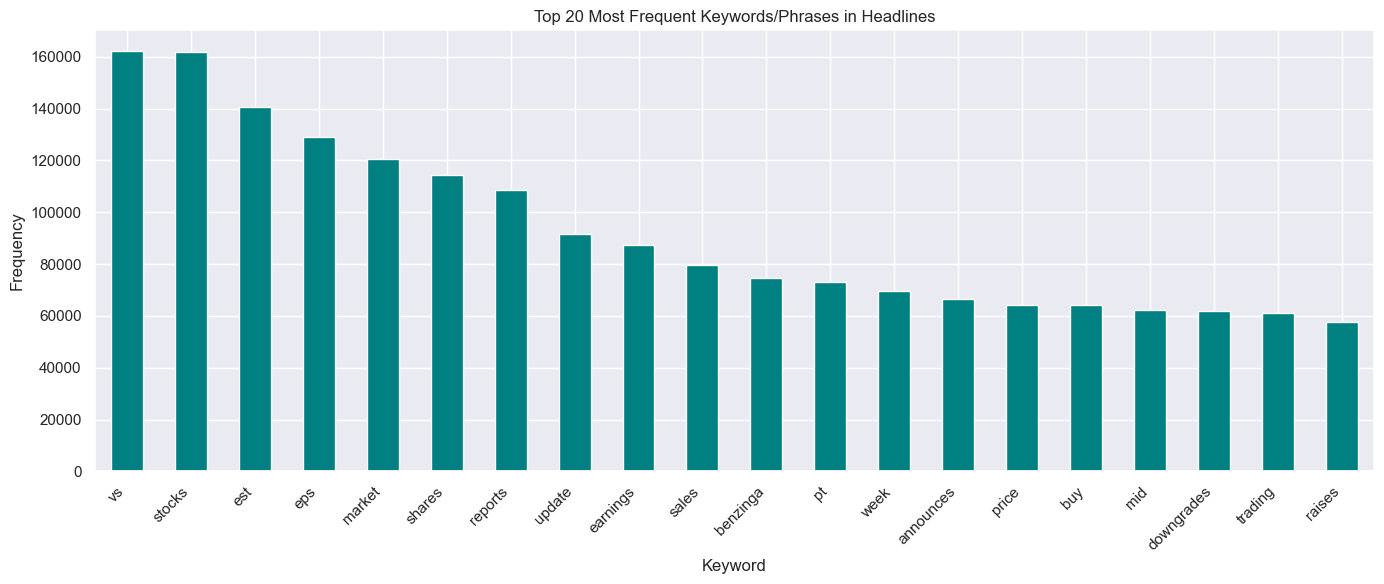

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=30,
    stop_words="english",
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["headline"].dropna())
word_freq = pd.Series(
    X.toarray().sum(axis=0),
    index=vectorizer.get_feature_names_out()
).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
word_freq.head(20).plot(kind="bar", color="teal", edgecolor="white")
plt.title("Top 20 Most Frequent Keywords/Phrases in Headlines")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("notebooks/top_keywords.png")
plt.show()

## Keyword Analysis Interpretation

The most frequent keywords reveal the dominant themes in financial
news: price targets, earnings beats/misses, analyst upgrades/
downgrades, and FDA approvals. These recurring themes form the
basis of market-moving narratives. Terms like "price target",
"earnings", "upgrade", and "downgrade" directly signal analyst
sentiment that influences stock price movements.

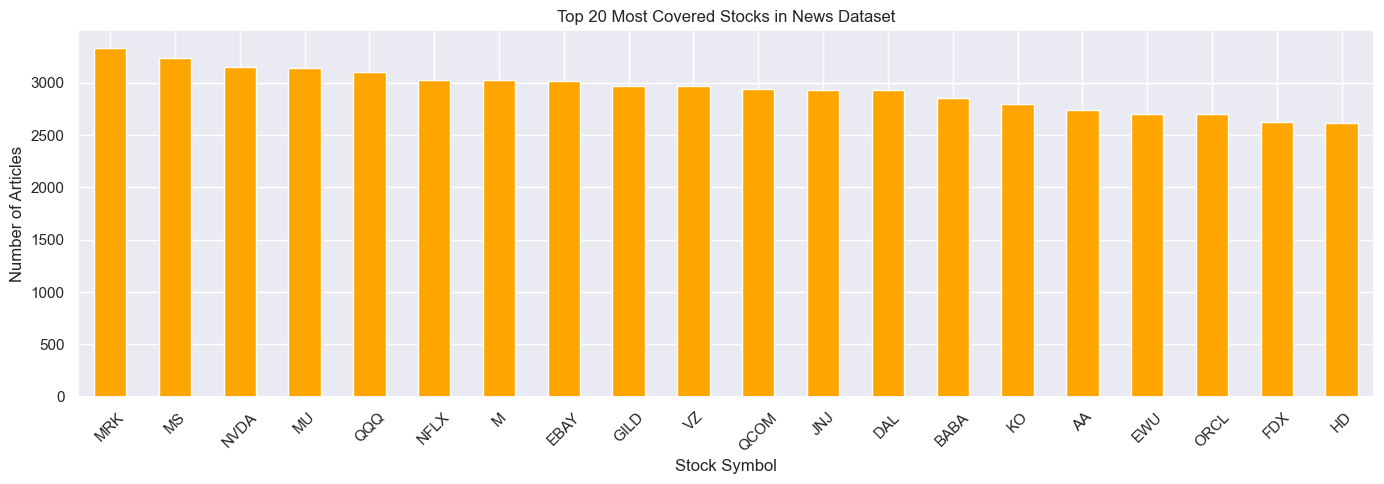

In [10]:
top_stocks = df["stock"].value_counts().head(20)

plt.figure(figsize=(14, 5))
top_stocks.plot(kind="bar", color="orange", edgecolor="white")
plt.title("Top 20 Most Covered Stocks in News Dataset")
plt.xlabel("Stock Symbol")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("notebooks/top_stocks.png")
plt.show()

## Stock Coverage Interpretation

Coverage is heavily concentrated in a small number of stocks,
reflecting the market capitalization bias of financial media.
Large-cap technology and pharmaceutical stocks dominate coverage.
This concentration means our sentiment-price correlation analysis
will be most reliable for heavily covered stocks like AAPL,
AMZN, GOOG, META, and NVDA — exactly the stocks in our price dataset.

In [11]:
summary = pd.DataFrame({
    "Metric": [
        "Total Articles",
        "Unique Stocks",
        "Unique Publishers",
        "Date Range Start",
        "Date Range End",
        "Avg Headline Length",
        "Most Active Publisher",
        "Most Covered Stock"
    ],
    "Value": [
        len(df),
        df["stock"].nunique(),
        df["publisher"].nunique(),
        str(df["date"].min().date()),
        str(df["date"].max().date()),
        f"{df['headline_length'].mean():.1f} chars",
        df["publisher"].value_counts().index[0],
        df["stock"].value_counts().index[0]
    ]
})
print(summary.to_string(index=False))

               Metric         Value
       Total Articles       1407328
        Unique Stocks          6204
    Unique Publishers          1034
     Date Range Start    2011-04-28
       Date Range End    2020-06-11
  Avg Headline Length    73.1 chars
Most Active Publisher Paul Quintaro
   Most Covered Stock           MRK
